In [ ]:
#Step 1: Descriptive Statistics & Univariate Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Load cleaned dataset
df = pd.read_excel("/content/TASK2 - Cleaned_ApexPlanet_DataAnalytics_Dataset.xlsx")

In [ ]:
# Summary Statistics
display(df.describe())

,age,quantity,unit_price,total_sales
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.342000,5.435000,25486.783410,139399.439650
std,13.684455,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,53.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


In [ ]:
# Categorical Summary
display(df.describe(include='object'))

,order_id,order_date,customer_id,customer_name,gender,city,product,category
count,1000,1000,1000,1000,1000,1000,1000,1000
unique,992,342,947,425,2,8,6,5
top,ORD100050,2025-04-16,CUST2515,Customer_359,Male,Patna,Mobile,Electronics
freq,9,10,3,8,511,148,184,354


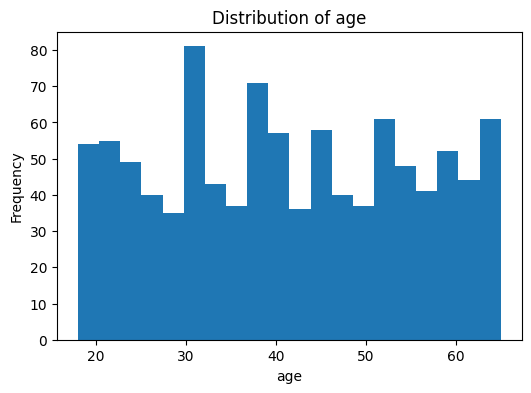

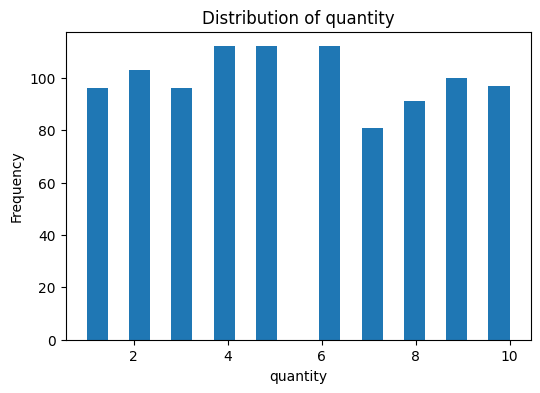

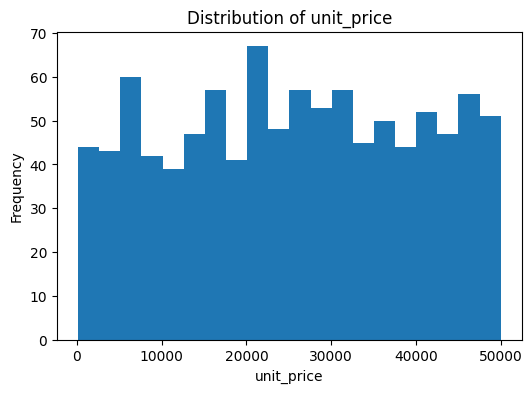

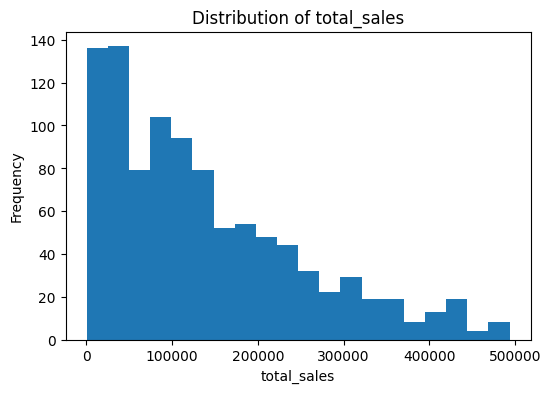

In [ ]:
#Histograms
numeric_cols = ['age', 'quantity', 'unit_price', 'total_sales']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

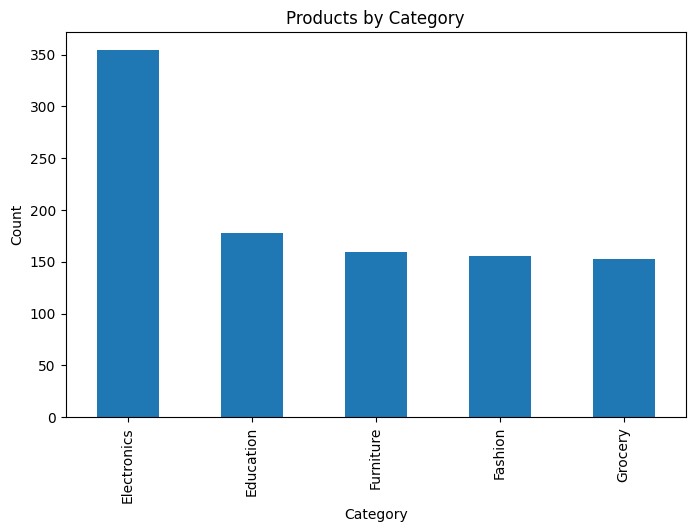

In [ ]:
#Bar Chart
plt.figure(figsize=(8,5))
df['category'].value_counts().plot(kind='bar')
plt.title("Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [ ]:
#Step 2: SQL for Business Questions

In [ ]:
#Create a SQL database
import sqlite3

conn = sqlite3.connect("sales.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

1000

In [ ]:
#Total Revenue
query = """
SELECT SUM(total_sales) AS Total_Revenue
FROM sales;
"""

pd.read_sql(query, conn)

,Total_Revenue
0,1.393994e+08


In [ ]:
#Top 5 Products by Revenue
query = """
SELECT product,
SUM(total_sales) AS Revenue
FROM sales
GROUP BY product
ORDER BY Revenue DESC
LIMIT 5;
"""

pd.read_sql(query, conn)

,product,Revenue
0,Laptop,25443008.51
1,Mobile,25335573.19
2,Book,25031689.40
3,Rice,22231711.28
4,Chair,21521561.48


In [ ]:
#Revenue by Category
query = """
SELECT category,
SUM(total_sales) AS Revenue
FROM sales
GROUP BY category;
"""

pd.read_sql(query, conn)

,category,Revenue
0,Education,25031689.40
1,Electronics,50778581.70
2,Fashion,19835895.79
3,Furniture,21521561.48
4,Grocery,22231711.28


In [ ]:
#Average Customer Age
query = """
SELECT AVG(age) AS Average_Age
FROM sales;
"""

pd.read_sql(query, conn)

,Average_Age
0,41.342


In [ ]:
#City-wise Sales
query = """
SELECT city,
SUM(total_sales) AS Revenue
FROM sales
GROUP BY city
ORDER BY Revenue DESC;
"""

pd.read_sql(query, conn)

,city,Revenue
0,Patna,20826584.43
1,Kolkata,18884349.57
2,Bengaluru,18773574.32
3,Mumbai,18757050.17
4,Hyderabad,17166766.87
5,Delhi,16097079.00
6,Pune,14513175.90
7,Gaya,14380859.39


In [ ]:
#Top Selling Categories
query = """
SELECT category,
COUNT(*) AS Orders
FROM sales
GROUP BY category
ORDER BY Orders DESC;
"""

pd.read_sql(query, conn)

,category,Orders
0,Electronics,354
1,Education,178
2,Furniture,159
3,Fashion,156
4,Grocery,153


In [ ]:
#Average Unit Price
query = """
SELECT AVG(unit_price) AS Average_Price
FROM sales;
"""

pd.read_sql(query, conn)

,Average_Price
0,25486.78341


In [ ]:
#Step 3: Multivariate Analysis & Correlation

In [ ]:
#Correlation Matrix
corr = df[['age','quantity','unit_price','total_sales']].corr()

print(corr)

                  age  quantity  unit_price  total_sales
age          1.000000 -0.028288   -0.011459     0.001270
quantity    -0.028288  1.000000    0.021855     0.646641
unit_price  -0.011459  0.021855    1.000000     0.686303
total_sales  0.001270  0.646641    0.686303     1.000000


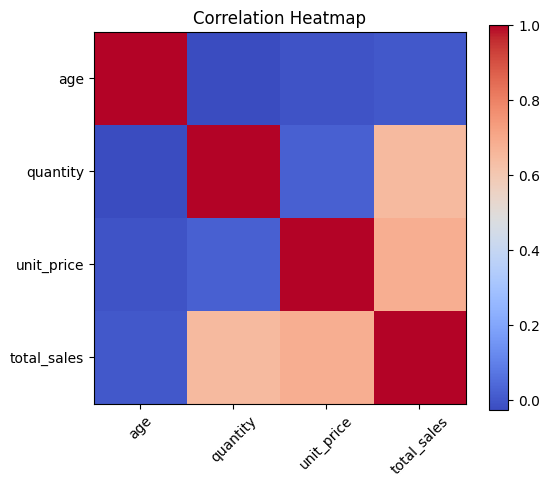

In [ ]:
#Heatmap
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

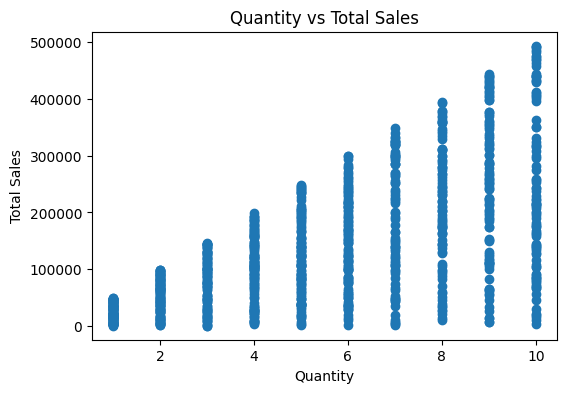

In [ ]:
#Scatter Plot
plt.figure(figsize=(6,4))
plt.scatter(df['quantity'], df['total_sales'])
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.title("Quantity vs Total Sales")
plt.show()

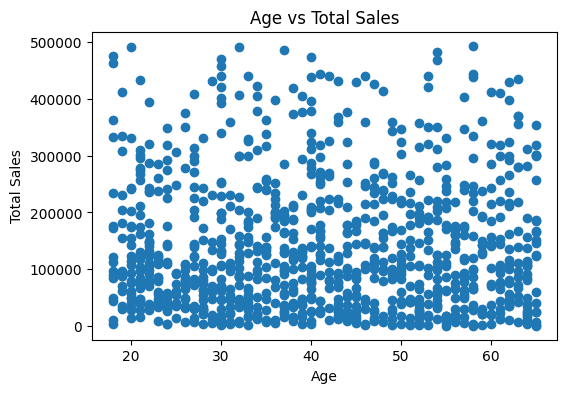

In [ ]:
#Scatter Plot
plt.figure(figsize=(6,4))
plt.scatter(df['age'], df['total_sales'])
plt.xlabel("Age")
plt.ylabel("Total Sales")
plt.title("Age vs Total Sales")
plt.show()